In [1]:
%pip install -r utils/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

# Set up paths - Data is in utils/Data/Clean/
waldo_path = '/workspaces/wheres-wally/utils/Data/Clean/ClearedWaldos/'
heads_path = '/workspaces/wheres-wally/utils/Data/Clean/OnlyWaldoHeads/'

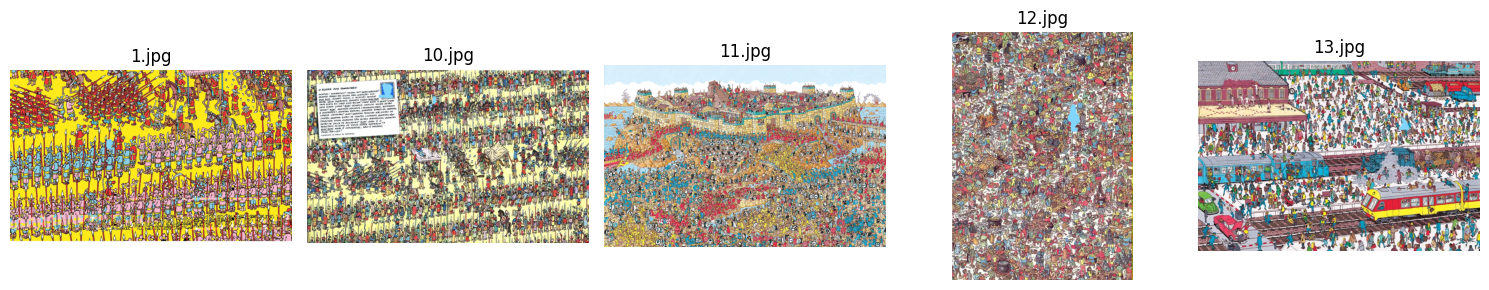

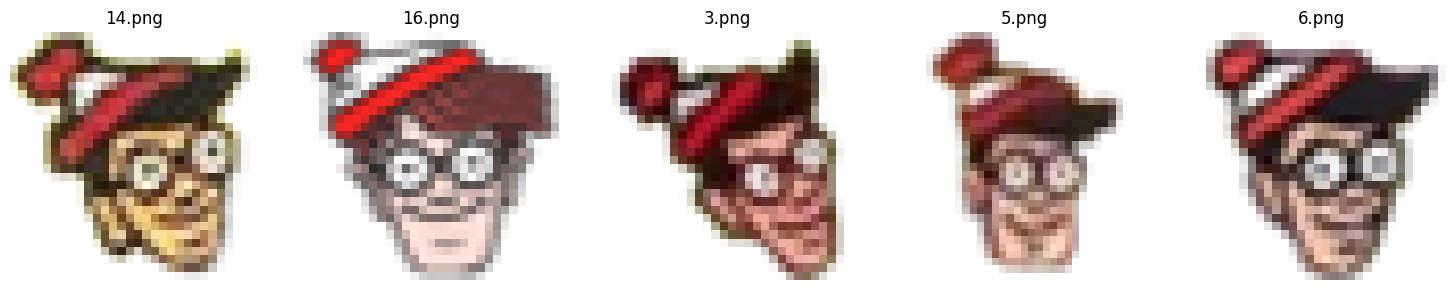

In [3]:
# Display examples of Only Wally
waldo_files = sorted([f for f in os.listdir(waldo_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(waldo_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(waldo_files[:num_samples]):
    img = mpimg.imread(os.path.join(waldo_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Display examples of Only Wally Heads
heads_files = sorted([f for f in os.listdir(heads_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(heads_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(heads_files[:num_samples]):
    img = mpimg.imread(os.path.join(heads_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import os
import sys

os.chdir('/workspaces/wheres-wally/utils')
sys.path.insert(0, '/workspaces/wheres-wally/utils')

try:
    from DataAugmentation import generating_waldos
    generating_waldos(sample_ratio=0.25, variations_per_combo=1)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    import traceback
    traceback.print_exc()

Error type: IndentationError
Error message: unexpected indent (DataAugmentation.py, line 98)


Traceback (most recent call last):
  File "/tmp/ipykernel_46241/3360259769.py", line 8, in <module>
    from DataAugmentation import generating_waldos
  File "/workspaces/wheres-wally/utils/DataAugmentation.py", line 98
    with Image.open(head_file) as head_img:
IndentationError: unexpected indent


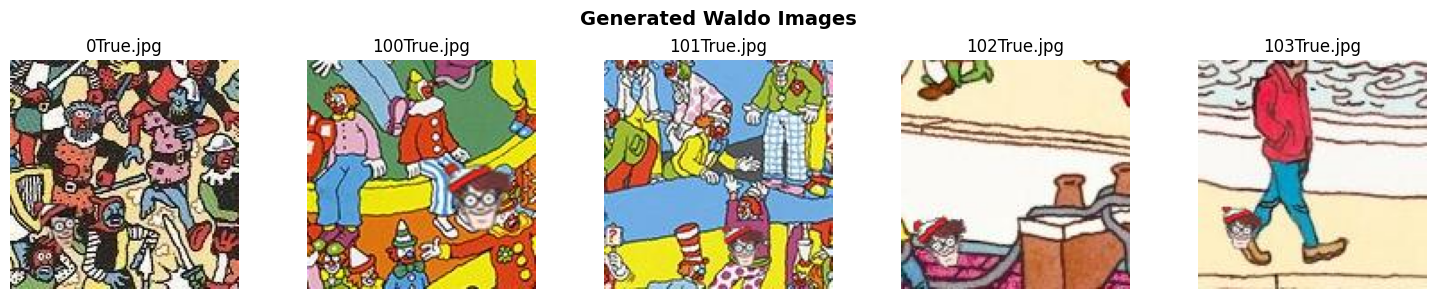

: 

In [ ]:
# List the generated Waldo images from the DataAugmentation output
waldo_generated_files = sorted([f for f in os.listdir('/workspaces/wheres-wally/utils/Data/Waldo') if f.endswith('.jpg')])[:5]

# Display 5 images from the generated Waldo dataset
fig, axes = plt.subplots(1, len(waldo_generated_files), figsize=(15, 3))
fig.suptitle('Generated Waldo Images', fontsize=14, fontweight='bold')

for idx, file in enumerate(waldo_generated_files):
    img = mpimg.imread(os.path.join('/workspaces/wheres-wally/utils/Data/Waldo', file))
    if len(waldo_generated_files) == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import sys
from pathlib import Path

# Define and add utils directory to Python path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

from TrainModel import train_waldo_model

# Create simple output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'waldo_model.h5'
data_dir = Path(utils_path) / 'Data'

# Train model from scratch
print("Training Waldo detection model from scratch...")
model, X_test, Y_test, score = train_waldo_model(
    data_path=str(data_dir),
    epochs=15,
    test_size=0.10,
    save_path=str(save_path)
)
print(f"✓ Model saved to: {save_path}")


2026-01-28 15:28:31.730174: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-28 15:28:31.731041: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 15:28:31.734251: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-28 15:28:31.741927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-28 15:28:31.754186: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 